In [1]:
import warnings
warnings.filterwarnings("ignore")

In [1]:
from ase.io.trajectory import Trajectory
from flonacomldft.collective_variables import get_collective_variables
import numpy as np
import torch
import pandas as pd

/mnt/home/amolina/miniconda3/envs/ml-dft/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path_database = '/mnt/home/amolina/ceph/adaptive-flow-mc/database/andersen/'
md_files = ['trajectories/27037382_is0_andersen.traj',  'trajectories/27037385_is1_andersen.traj']

trajs = {i: Trajectory(path_database + md_files[i])[200:] for i in range(len(md_files))}

In [3]:
len(trajs[0]), len(trajs[1])

(9801, 9801)

In [4]:
temperature = {i: np.array([molecule.get_temperature() for molecule in trajs[i]]) for i in trajs.keys()}

In [5]:
from flonacomldft.utils.io_utils import save_ase_molecules_as_traj

In [6]:
trajs = {i: trajs[i][::10] for i in range(len(md_files))}

In [9]:
len(trajs[0][:50])


50

In [10]:
len(trajs[1][:50])

50

In [ ]:
save_ase_molecules_as_traj(trajs[0][:100], 'is0_md.traj')
save_ase_molecules_as_traj(trajs[1][:100], 'is1_md.traj')

In [23]:
import matplotlib.pyplot as plt

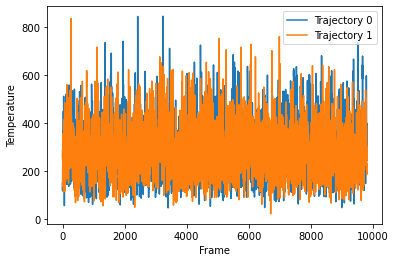

In [26]:
plt.plot(temperature[0], label='Trajectory 0')
plt.plot(temperature[1], label='Trajectory 1')
plt.xlabel('Frame')
plt.ylabel('Temperature')
plt.legend()
plt.show()


In [35]:
u = {i: np.array([molecule.get_potential_energy() for molecule in trajs[i]]) for i in trajs.keys()}

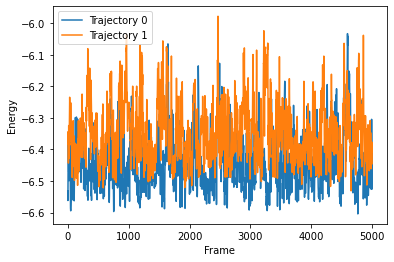

In [36]:
plt.plot(u[0][100:5100], label='Trajectory 0')
plt.plot(u[1][100:5100], label='Trajectory 1')
plt.xlabel('Frame')
plt.ylabel('Energy')
plt.legend()
plt.show()


In [6]:
cv = {i: np.stack([get_collective_variables(molecule) for molecule in trajs[i][:5]]) for i in trajs.keys()}

In [12]:
import torch
from flonacomldft.internal_coordinates import Coordinates_mapping

In [13]:
from flonacomldft.internal_coordinates import save_internal_coordinates_to_csv

In [14]:
coord_mapping = Coordinates_mapping()
dim = 12
isomer_label = 0

In [15]:
zmats = coord_mapping.get_internal_from_trajectory(trajectory=trajs[isomer_label][:5], 
                                            isomer=isomer_label,
                                            temperature=350, 
                                            add_potential_energy=True,
                                            add_cvs=True,)

In [28]:
'27037382_is0_andersen.traj'.split('/')[-1].split('.')[0]+ '_zmats' + '.csv'

'27037382_is0_andersen_zmats.csv'

In [17]:
from flonacomldft.utils.silver_isomers_utils import get_construction_table
construction_table = get_construction_table()
save_internal_coordinates_to_csv(zmats, 
                                construction_table=construction_table, 
                                filename='internal_coordinates_is{:d}.csv'.format(isomer_label), 
                                path=path_database + '/internal_coordinates')

In [19]:
coord_xs, logdetjac_xs, energies_xs = coord_mapping.get_real_centered_from_internal(zmats[:, :dim], 
                                                    isomer=isomer_label, 
                                                    temperature=350,
                                                    energies=zmats[:, dim],
                                                    logdetjacs=zmats[:, dim+2])

In [20]:
xs = torch.cat([coord_xs, 
                energies_xs.reshape(-1, 1),
                torch.ones(coord_xs.shape[0]).reshape(-1, 1)*isomer_label,
                logdetjac_xs.reshape(-1, 1),
                zmats[:, -2:]], dim=1)

In [22]:
columns = ['rc{:d}' for i in range(dim)]
save_internal_coordinates_to_csv( xs, 
                                columns=columns, 
                                filename='real_centered_coordinates_is{:d}.csv'.format(isomer_label), 
                                path=path_database + '/internal_coordinates')

In [29]:
from flonacomldft.utils.io_utils import get_path, load_pickle_file
import torch

In [30]:
flow_models = [ load_pickle_file('dict_flow_model_is'+str(i)+'.pkl', get_path() + '/andersen/models/')['model'] for i in range(2)]
mlp_model = [load_pickle_file('dict_mlp_model_is'+str(i)+'.pkl', get_path() + '/andersen/models/')['model'] for i in range(2)]

In [31]:
from flonacomldft.models.mixture import Mixture

flow_model = Mixture(flow_models, torch.tensor([0.5, 0.5]))

In [32]:
n_chains = 10
n_steps = 20
xs_init = flow_model.sample(n_chains)
us_init = mlp_model[0](xs_init)
isomers_init = torch.zeros(n_chains, 1)

init = torch.cat([xs_init, us_init, isomers_init], dim=1)

In [5]:
from flonacomldft.sampling import run_metropolis

In [34]:
mh = run_metropolis(model = flow_model, 
                init = init, 
                n_chains = n_chains,
                n_steps = n_steps,
                id_run = 'N/A', 
                energy_type = 'mlp', 
                temperature = 350,
                mixture = True,
                mlp_models = mlp_model,
                frac_computed = 0.2,
                dim = 12,
                update_weights = True,
                scheduler_weights = 5,
                alpha = 0.5,
                return_ratios = False,
                return_proposals = True,
                with_tqdm = False,
                folder_name = None,
                )

Running Metropolis-Hastings
Number of chains: 10
Number of steps: 20
Temperature: 350K
Energy Type: mlp
Mixture model
Use Neural Predictor: True
Mixture Model: True
Step 	 Acc Rate 	 Population
0 	 0.800 		 0.300
1 	 0.500 		 0.200
2 	 0.500 		 0.100
3 	 0.300 		 0.000
4 	 0.300 		 0.000
5 	 0.400 		 0.000
6 	 0.300 		 0.000
7 	 0.100 		 0.000
8 	 0.200 		 0.000
9 	 0.300 		 0.000
10 	 0.100 		 0.000
11 	 0.200 		 0.000
12 	 0.400 		 0.000
13 	 0.400 		 0.000
14 	 0.300 		 0.000
15 	 0.200 		 0.000
16 	 0.200 		 0.000
17 	 0.300 		 0.000
18 	 0.400 		 0.000
19 	 0.100 		 0.000


In [35]:
from flonacomldft.utils.io_utils import load_csv_file
from flonacomldft.train_flow_from_data import train_flow
from flonacomldft.train_mlp_from_data import train_mlp

In [36]:
#flow_train = [load_csv_file('is'+str(i)+'_flow_train.csv', get_path() + '/andersen/datasets')[:, :14]
#              for i in range(2)]
#flow_test = [load_csv_file('is'+str(i)+'_flow_test.csv', get_path() + '/andersen/datasets')[:, :14]
#                for i in range(2)]

from flonacomldft.utils.data_processing import load_datasets

flow_train = []
flow_test = []

isomer_labels = [0, 1]

for isomer_label in isomer_labels:
    
    dataset = load_datasets('andersen', isomer_label, name='flow', real_centered=True)
    flow_train.append(dataset['train'].clone())
    flow_test.append(dataset['test'].clone())

    del dataset

In [37]:
dict_flow_models = [ load_pickle_file('dict_flow_model_is'+str(i)+'.pkl', get_path() + '/andersen/models/') for i in range(2)]
dict_mlp_models = [load_pickle_file('dict_mlp_model_is'+str(i)+'.pkl', get_path() + '/andersen/models/') for i in range(2)]

In [38]:
n_runs = 5
n_chains = 10
n_steps = 5

flow_hyperparams = {'n_iter': 10,
    'lr': 1e-3,
    'bs': 200,
    'use_scheduler': True,
    'step_scheduler': 10,
    'save_splits': 1,
    'grad_clip': 1e4,
    }

mlp_hyperparams = {'n_iter': 10,
    'lr': 1e-3,
    'bs': 200,
    'use_scheduler': True,
    'step_schedule': 100,
    'save_splits': 1,
    }

In [39]:
from flonacomldft.full_adaptive_sampling import run_adaptive_sampling

In [40]:
adaptive_sampling = run_adaptive_sampling(mcmc_init=init, 
                n_chains=n_chains,
                n_steps=n_steps,
                n_runs=n_runs,
                flow_init_train=flow_train,
                flow_init_test=flow_test,
                dict_flows_init=dict_flow_models,
                flow_hyperparams=[flow_hyperparams, flow_hyperparams],
                energy_type='emt-mlp',
                temperature=350,
                mixture=True,
                dim=12,
                dict_mlps_init=dict_mlp_models,
                mlp_init_train=flow_train,
                mlp_init_test=flow_test,
                mlp_hyperparams=[mlp_hyperparams, mlp_hyperparams],
                train_mlp_models=True,
                frac_computed=0.2,
                init_weights=None,
                update_weights=True,
                scheduler_weights=10,
                n_samples_train_flow=None,
                folder_name='',
                alpha=0.5,
                device='cpu',
)

Adaptive sampling
Number of runs:  5
Number of chains:  10
Number of steps:  5
Temperature:  350
Energy type:  emt-mlp
Mixture model:  True
Isomer labels:  [0, 1]
Flow train dataset shapes:  [[4000, 14], [4000, 14]]
Flow test dataset shapes:  [[1000, 14], [1000, 14]]
tensor([4000, 4000])
tensor([200, 200])
tensor([20, 20], dtype=torch.int32)
MLP train dataset shapes:  [[4000, 14], [4000, 14]]
MLP test dataset shapes:  [[1000, 14], [1000, 14]]
Initial weights:  [0.5, 0.5]
Number of samples for training flows:  [4000, 4000]
Current weights:  [0.5, 0.5]
Running Metropolis-Hastings
Number of chains: 10
Number of steps: 5
Temperature: 350K
Energy Type: emt-mlp
Mixture model
Use Neural Predictor: True
Use EMT Calculator: True
Mixture Model: True
Step 	 Acc Rate 	 Population
0 	 0.600 		 0.200
1 	 0.500 		 0.200
2 	 0.300 		 0.000
3 	 0.500 		 0.000
4 	 0.200 		 0.000
Isomer:  0
Flow train dataset shape:  [4000, 14]
Flow chains dataset shape:  [46, 14]
Flow train dataset shape:  [4046, 14]
Fl

In [41]:
from flonacomldft.train_flow_from_data import train_flow

In [42]:
flow = train_flow(
        model=flow_models[0],
        train=flow_train[0],
        n_iter=100,
        lr=1e-3,
        bs=200,
        use_scheduler=True,
        step_scheduler=10,
        save_splits=1,
        grad_clip=1e4,
        with_tqdm=False,
        n_partial_loss=10,
        dim=12
)

Epoch 		 Lr 		 Loss 		 Grad norm
0.0e+00 	 1.00e-03 	 -9.71e+00 	 2e+01
1.0e+01 	 5.00e-04 	 -1.09e+01 	 7e+00
2.0e+01 	 2.50e-04 	 -1.11e+01 	 4e+00
3.0e+01 	 1.25e-04 	 -1.11e+01 	 4e+00
4.0e+01 	 6.25e-05 	 -1.12e+01 	 4e+00
5.0e+01 	 3.13e-05 	 -1.12e+01 	 4e+00
6.0e+01 	 1.56e-05 	 -1.12e+01 	 4e+00
7.0e+01 	 7.81e-06 	 -1.12e+01 	 4e+00
8.0e+01 	 3.91e-06 	 -1.12e+01 	 4e+00
9.0e+01 	 1.95e-06 	 -1.12e+01 	 4e+00


In [47]:
flow.keys()

dict_keys(['model', 'losses', 'grad_norms', 'time_step'])

In [44]:
import copy
import time
import torch
import tqdm
from torch.nn.utils import clip_grad_norm_

def train_mlp(
    model,
    train,
    test,
    n_iter,
    lr,
    bs,
    use_scheduler=False,
    step_scheduler=10,
    save_splits=1,
    grad_clip=1e4,
    with_tqdm=False,
    n_partial_loss=10,
    dim=12,  
    ):
    
    def loss_func(x, y):
        return ((model(x).squeeze() - y)**2).mean()
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    if use_scheduler:
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 
                                                    step_size=step_scheduler, 
                                                    gamma=0.5)
        
    if save_splits > 1:
        models = [copy.deepcopy(model)]

    if with_tqdm:
        pbar = tqdm.tqdm(range(n_iter))
    else:
        pbar = range(n_iter)
        print('Epoch \t\t Lr \t\t Train Loss \t Test Loss \t Grad norm')


    train_losses = []
    test_losses = []
    grad_norms = []
    time_step = []

    x_train, y_train = train[:, :dim], train[:, dim]
    x_test, y_test = test[:, :dim], test[:, dim]

    permutation = torch.randperm(x_train.size()[0])

    for t in pbar:

        for k in range(0, x_train.size()[0], bs):

            indices = permutation[k:k+bs]
            x_batch, y_batch = x_train[indices].detach(), y_train[indices].detach()

            optimizer.zero_grad()
            loss = loss_func(x_batch, y_batch)
            
            if torch.isinf(loss).any():
                print('Stopped because loss became of inf!')
                return {'model': model, 
                        'train_loss': train_losses, 
                        'test_losses': test_losses}

            loss.backward()
            clip_grad_norm_(model.parameters(), max_norm=grad_clip)

            optimizer.step()

            train_losses.append(loss.item())
            test_losses.append(loss_func(x_test, y_test).item())

            time_step.append(time.time())

        if t % (n_iter / 100) == 0:
            total_norm = 0
            for p in model.parameters():
                param_norm = p.grad.detach().data.norm(2)
                total_norm += param_norm.item() ** 2
            total_norm = total_norm**0.5
            grad_norms.append(total_norm)

        if use_scheduler:
            scheduler.step()

        if with_tqdm == False:

            if t % (n_iter // n_partial_loss) == 0:

                for param_group in optimizer.param_groups:
                    lr_ = param_group['lr']

                print('{:0.1e} \t {:0.2e} \t {:3.2e} \t {:3.2e} \t {:0.1e}'.format(t, lr_, train_losses[-1], test_losses[-1], grad_norms[-1]))

        else:

            pbar.set_description('Loss: {:.4f}'.format(train_losses[-1]))


        if save_splits > 1:
            if t % (n_iter // save_splits) == 0:
                models.append(copy.deepcopy(model))

    to_return = {'model': model,
                'train_losses': train_losses,
                'test_losses': test_losses,
                'grad_norms': grad_norms,
                'time_step': time_step}
    
    if save_splits > 1:
        to_return['models'] = models

    return to_return

In [45]:
mlp = train_mlp(model=mlp_model[0],
    train=flow_train[0],
    test=flow_test[0],
    n_iter=100,
    lr=1e-3,
    bs=200,
    use_scheduler=True,
    step_scheduler=10,
    save_splits=1,
    grad_clip=1e4,
    with_tqdm=False,
    n_partial_loss=10,
    dim=12
)

Epoch 		 Lr 		 Train Loss 	 Test Loss 	 Grad norm


0.0e+00 	 1.00e-03 	 2.34e-01 	 2.63e-01 	 1.4e+01
1.0e+01 	 5.00e-04 	 2.15e-03 	 1.92e-03 	 3.1e-01
2.0e+01 	 2.50e-04 	 1.70e-03 	 1.55e-03 	 3.7e-02
3.0e+01 	 1.25e-04 	 1.61e-03 	 1.42e-03 	 1.3e-01
4.0e+01 	 6.25e-05 	 1.56e-03 	 1.37e-03 	 1.3e-01
5.0e+01 	 3.13e-05 	 1.52e-03 	 1.34e-03 	 1.0e-01
6.0e+01 	 1.56e-05 	 1.50e-03 	 1.32e-03 	 9.3e-02
7.0e+01 	 7.81e-06 	 1.49e-03 	 1.31e-03 	 9.2e-02
8.0e+01 	 3.91e-06 	 1.48e-03 	 1.31e-03 	 9.1e-02
9.0e+01 	 1.95e-06 	 1.48e-03 	 1.30e-03 	 9.0e-02


In [46]:
mlp.keys()

dict_keys(['model', 'train_losses', 'test_losses', 'grad_norms', 'time_step'])

# MCMC Energy - No weird gap, some model was a wrong copy, probably

In [22]:
from flonacomldft.sampling import run_metropolis
from flonacomldft.models.mixture import Mixture
from flonacomldft.utils.io_utils import get_path, load_pickle_file, load_csv_file
from flonacomldft.utils.plots import plot_energy_histogram

In [7]:
DFT_SIMS_PATH = '/mnt/home/amolina/ceph/adaptive-350/adaptive-dft/'

adaptive_dft_path = ['1-adaptive/results_adaptive_is0_28685740/adaptive_sampling_is0_28685740.pkl',
                    '1-adaptive/results_adaptive_is1_28685741/adaptive_sampling_is1_28685741.pkl']

mcmc_paths = '5-multimodal/results_multimodal_sampling_mixture_29096190/mixture_mcmc_dic_29096190.pkl'

In [8]:
path_mlps = '/mnt/home/amolina/ceph/ml-dft/database/andersen/models'
mlp_models = [load_pickle_file('dict_mlp_model_is{:d}_adaptive.pkl'.format(i), path_mlps)['model'] for i in [0, 1]]
adaptives = {i: load_pickle_file(adaptive_dft_path[i], DFT_SIMS_PATH) for i in [0, 1]}

In [9]:
flow_models = [adaptives[i]['dict_flows_training'][-1][0]['model'] for i in [0, 1]]
mixture_model = Mixture(flow_models, torch.tensor([0.5, 0.5]))

In [10]:
n_chains = 50
n_steps = 1000

xs_is0 = load_csv_file('is0_flow_train.csv', get_path() + '/andersen/datasets')
xs_is1 = load_csv_file('is1_flow_train.csv', get_path() + '/andersen/datasets')
xs_init = torch.cat((xs_is0[:int(n_chains/2)], xs_is1[:int(n_chains/2)]))

In [11]:
_ = run_metropolis(
    model=mixture_model,
    init=xs_init,
    mlp_models=mlp_models,
    n_steps=n_steps,
    n_chains=n_chains,
    id_run='N/A',
    mixture=True,
    temperature=350,
    energy_type='mlp',
)

Running Metropolis-Hastings
Number of chains: 50
Number of steps: 1000
Temperature: 350.0K
Energy Type: mlp
Mixture model
Use Neural Predictor: True
Mixture Model: True
Step 	 Acc Rate
0 	 0.540
1 	 0.380
2 	 0.300
3 	 0.200
4 	 0.300
5 	 0.300
6 	 0.320
7 	 0.260
8 	 0.280
9 	 0.300
10 	 0.200
11 	 0.340
12 	 0.420
13 	 0.420
14 	 0.320
15 	 0.320
16 	 0.320
17 	 0.300
18 	 0.380
19 	 0.340
20 	 0.340
21 	 0.280
22 	 0.360
23 	 0.260
24 	 0.340
25 	 0.260
26 	 0.300
27 	 0.240
28 	 0.240
29 	 0.360
30 	 0.320
31 	 0.300
32 	 0.280
33 	 0.260
34 	 0.260
35 	 0.360
36 	 0.320
37 	 0.300
38 	 0.260
39 	 0.240
40 	 0.280
41 	 0.260
42 	 0.280
43 	 0.360
44 	 0.340
45 	 0.300
46 	 0.340
47 	 0.240
48 	 0.260
49 	 0.280
50 	 0.260
51 	 0.320
52 	 0.320
53 	 0.400
54 	 0.340
55 	 0.360
56 	 0.220
57 	 0.360
58 	 0.320
59 	 0.300
60 	 0.280
61 	 0.320
62 	 0.220
63 	 0.280
64 	 0.320
65 	 0.340
66 	 0.220
67 	 0.240
68 	 0.320
69 	 0.220
70 	 0.340
71 	 0.360
72 	 0.320
73 	 0.300
74 	 0.380


In [13]:
mcmc = load_pickle_file(mcmc_paths, DFT_SIMS_PATH)

<AxesSubplot:xlabel='Energy (eV)', ylabel='Density (u.a.)'>

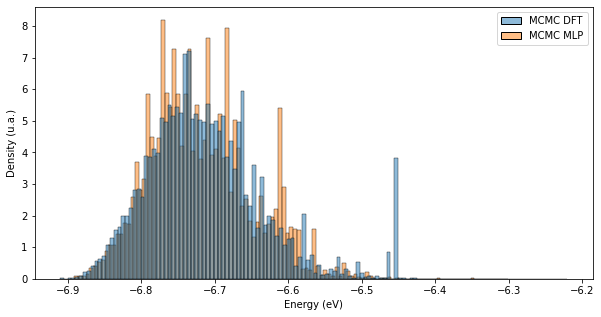

In [15]:
energy = {
    'MCMC DFT': mcmc['us'].flatten().detach().numpy(),
    'MCMC MLP': _['us'].flatten().detach().numpy()
          }

plot_energy_histogram(energy)

In [3]:
from flonacomldft.utils.io_utils import get_project_path
from flonacomldft.utils.plots import plot_energy_histogram

In [47]:
isomer = 0
n_id = 29941690
project_path = get_project_path()
results_folder = project_path + '/1-adaptive/results_adaptive_is{:d}_{:d}'.format(isomer, n_id)

In [48]:
path_xs_proposals_save = 'xs_proposals_is{:d}_{:d}.csv'.format(isomer, n_id)
xs_proposals = pd.read_csv(results_folder+'/'+path_xs_proposals_save)
path_xs_proposals_comp = 'is{:d}_proposals_xs_{:d}.csv'.format(isomer, n_id)
xs_proposals_comp = pd.read_csv(results_folder+'/'+path_xs_proposals_comp)

In [50]:
xs_proposals.shape, xs_proposals_comp.shape

((31500, 14), (30000, 14))

In [51]:
energies_proposals = {
    'file': xs_proposals['potential_energy'],#[50:1050],
    'read': xs_proposals_comp['potential_energy'],#[0:1000],
}

<AxesSubplot:xlabel='Energy (eV)', ylabel='Density (u.a.)'>

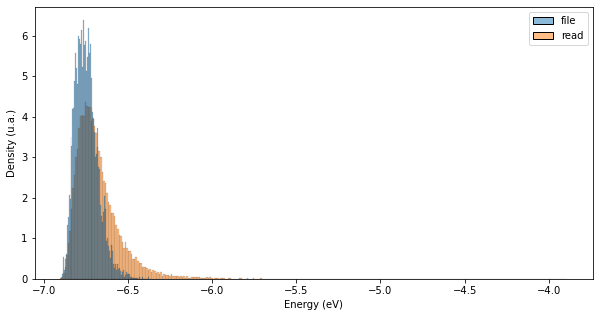

In [52]:
plot_energy_histogram(energies_proposals)